In [27]:
from pathlib import Path
import csv
import matplotlib.pyplot as plt
import numpy as np

from utils import graphics
from buryn_utils import spikes_utils

graphics.set_matplotlib_settings()


In [ ]:
BURYNOUTPUTS_DIRS = [
    "../data/buryn_data/buryn_outputs_01",
]
EXCITATORY_POP_RATE_NPYS = [Path(burynoutputs_dir+'/plots/exc_population_rate.npy') for burynoutputs_dir in BURYNOUTPUTS_DIRS]
INHIBITORY_POP_RATE_NPYS = [Path(burynoutputs_dir+'/plots/inh_population_rate.npy') for burynoutputs_dir in BURYNOUTPUTS_DIRS]
STEP_MIN = 0
STEP_MAX = 100000
NUM_NEURONS_TO_PLOT = 2500
STIMULATION_START_STEPS = [5000, 13478, 19887, 30393, 40405, 50062, 58348, 66027, 80962, 88386]
STIMULATION_END_STEPS = [6000, 14478, 20887, 31393, 41405, 51062, 59348, 67027, 81962, 89386]

for path in EXCITATORY_POP_RATE_NPYS:
    if not path.exists():
        raise FileNotFoundError(f"Could not find {path.resolve()}")
for path in INHIBITORY_POP_RATE_NPYS:
    if not path.exists():
        raise FileNotFoundError(f"Could not find {path.resolve()}")

In [29]:
excitatory_pop_rates = [np.load(excitatory_pop_rate_npy) for excitatory_pop_rate_npy in EXCITATORY_POP_RATE_NPYS]
inhibitory_pop_rates = [np.load(inhibitory_pop_rate_npy) for inhibitory_pop_rate_npy in INHIBITORY_POP_RATE_NPYS]

In [30]:
mean_excitatory_pop_rate = np.mean(np.array(excitatory_pop_rates), axis=0)
mean_inhibitory_pop_rate = np.mean(np.array(inhibitory_pop_rates), axis=0)

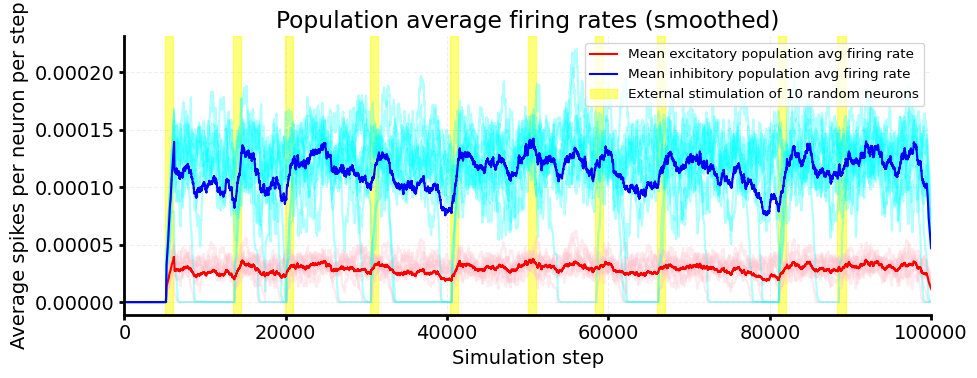

In [31]:

fig, ax = plt.subplots(figsize=(10, 4))
for excitatory_pop_rate in excitatory_pop_rates:
    ax.plot(excitatory_pop_rate, color='pink', alpha=0.3)
for inhibitory_pop_rate in inhibitory_pop_rates:
    ax.plot(inhibitory_pop_rate, color='cyan', alpha=0.3)
ax.plot(mean_excitatory_pop_rate, color='red', label='Mean excitatory population avg firing rate')
ax.plot(mean_inhibitory_pop_rate, color='blue', label='Mean inhibitory population avg firing rate')
assert len(STIMULATION_START_STEPS) == len(STIMULATION_END_STEPS), "STIMULATION_START_STEPS and STIMULATION_END_STEPS must have the same length"
i=0
start_step = STIMULATION_START_STEPS[i]
end_step = STIMULATION_END_STEPS[i]
ax.axvspan(start_step, end_step, color='yellow', alpha=0.5, label='External stimulation of 10 random neurons')
for i in range(1, len(STIMULATION_START_STEPS)):
    start_step = STIMULATION_START_STEPS[i]
    end_step = STIMULATION_END_STEPS[i]
    ax.axvspan(start_step, end_step, color='yellow', alpha=0.5)
ax.set_title('Population average firing rates (smoothed)')
ax.set_xlabel('Simulation step')
ax.set_ylabel('Average spikes per neuron per step')
ax.set_xlim(STEP_MIN, STEP_MAX)
ax.grid(True, linestyle='--', alpha=0.2)
ax.legend()
fig.tight_layout()
plt.show()